In [ ]:
import numpy as np
import pandas as pd
#استدعاء مكتبتين نمباي وباندز

In [ ]:
from google.colab import files
uploaded = files.upload()
#كود رفع الداتاست

Saving nyc-rolling-sales.csv to nyc-rolling-sales.csv


In [ ]:
df=pd.read_csv("nyc-rolling-sales.csv")
df.shape
#قراءة البيانات وحفظها في متغير واستعراض معلوماتها


(84548, 22)

In [ ]:
df.head()
#استعراض اول خمس صفوف في الجدول

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [ ]:
df.info()
#فحص انواع العواميد

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [ ]:
print(df['EASE-MENT'].unique())
#التأكد من خلو العمود من قيم جوهرية

[' ']


خطة المعالجة رقم1  /


1- حذف عامودين EASE-MENT and Unnamed: 0   
2- تعديل اانواع العواميد المختلفة
3- اعادة فحص عبر info()


In [ ]:
df = df.drop(columns=["Unnamed: 0", "EASE-MENT"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   BOROUGH                         84548 non-null  int64 
 1   NEIGHBORHOOD                    84548 non-null  object
 2   BUILDING CLASS CATEGORY         84548 non-null  object
 3   TAX CLASS AT PRESENT            84548 non-null  object
 4   BLOCK                           84548 non-null  int64 
 5   LOT                             84548 non-null  int64 
 6   BUILDING CLASS AT PRESENT       84548 non-null  object
 7   ADDRESS                         84548 non-null  object
 8   APARTMENT NUMBER                84548 non-null  object
 9   ZIP CODE                        84548 non-null  int64 
 10  RESIDENTIAL UNITS               84548 non-null  int64 
 11  COMMERCIAL UNITS                84548 non-null  int64 
 12  TOTAL UNITS                     84548 non-null

In [ ]:
numeric_cols = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET']

In [ ]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df[numeric_cols].isnull().sum()

,0
SALE PRICE,14561
LAND SQUARE FEET,26252
GROSS SQUARE FEET,27612


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         84548 non-null  int64  
 1   NEIGHBORHOOD                    84548 non-null  object 
 2   BUILDING CLASS CATEGORY         84548 non-null  object 
 3   TAX CLASS AT PRESENT            84548 non-null  object 
 4   BLOCK                           84548 non-null  int64  
 5   LOT                             84548 non-null  int64  
 6   BUILDING CLASS AT PRESENT       84548 non-null  object 
 7   ADDRESS                         84548 non-null  object 
 8   APARTMENT NUMBER                84548 non-null  object 
 9   ZIP CODE                        84548 non-null  int64  
 10  RESIDENTIAL UNITS               84548 non-null  int64  
 11  COMMERCIAL UNITS                84548 non-null  int64  
 12  TOTAL UNITS                     

In [ ]:
df["SALE PRICE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84548 entries, 0 to 84547
Series name: SALE PRICE
Non-Null Count  Dtype  
--------------  -----  
69987 non-null  float64
dtypes: float64(1)
memory usage: 660.7 KB


In [ ]:
df = df.dropna(subset=['SALE PRICE'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69987 entries, 0 to 84547
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         69987 non-null  int64  
 1   NEIGHBORHOOD                    69987 non-null  object 
 2   BUILDING CLASS CATEGORY         69987 non-null  object 
 3   TAX CLASS AT PRESENT            69987 non-null  object 
 4   BLOCK                           69987 non-null  int64  
 5   LOT                             69987 non-null  int64  
 6   BUILDING CLASS AT PRESENT       69987 non-null  object 
 7   ADDRESS                         69987 non-null  object 
 8   APARTMENT NUMBER                69987 non-null  object 
 9   ZIP CODE                        69987 non-null  int64  
 10  RESIDENTIAL UNITS               69987 non-null  int64  
 11  COMMERCIAL UNITS                69987 non-null  int64  
 12  TOTAL UNITS                     69987

In [ ]:
print("عدد الصفوف المتبقية بعد حذف الفراغات من سعر البيع:", df.shape[0])

عدد الصفوف المتبقية بعد حذف الفراغات من سعر البيع: 69987


In [ ]:
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69987 entries, 0 to 84547
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         69987 non-null  int64         
 1   NEIGHBORHOOD                    69987 non-null  object        
 2   BUILDING CLASS CATEGORY         69987 non-null  object        
 3   TAX CLASS AT PRESENT            69987 non-null  object        
 4   BLOCK                           69987 non-null  int64         
 5   LOT                             69987 non-null  int64         
 6   BUILDING CLASS AT PRESENT       69987 non-null  object        
 7   ADDRESS                         69987 non-null  object        
 8   APARTMENT NUMBER                69987 non-null  object        
 9   ZIP CODE                        69987 non-null  int64         
 10  RESIDENTIAL UNITS               69987 non-null  int64         
 11  COMMERC

In [ ]:
df['SALE_YEAR'] = df['SALE DATE'].dt.year

In [ ]:
df["SALE_YEAR"]

,SALE_YEAR
0,2017
3,2016
4,2016
6,2016
9,2016
...,...
84543,2016
84544,2017
84545,2017
84546,2016


In [ ]:
df['SALE_MONTH'] = df['SALE DATE'].dt.month

In [ ]:
df["SALE_MONTH"]

,SALE_MONTH
0,7
3,9
4,11
6,9
9,11
...,...
84543,11
84544,4
84545,7
84546,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69987 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         69987 non-null  int64         
 1   NEIGHBORHOOD                    69987 non-null  object        
 2   BUILDING CLASS CATEGORY         69987 non-null  object        
 3   TAX CLASS AT PRESENT            69987 non-null  object        
 4   BLOCK                           69987 non-null  int64         
 5   LOT                             69987 non-null  int64         
 6   BUILDING CLASS AT PRESENT       69987 non-null  object        
 7   ADDRESS                         69987 non-null  object        
 8   APARTMENT NUMBER                69987 non-null  object        
 9   ZIP CODE                        69987 non-null  int64         
 10  RESIDENTIAL UNITS               69987 non-null  int64         
 11  COMMERC

In [ ]:
df[['SALE DATE', 'SALE_YEAR', 'SALE_MONTH']].head()

,SALE DATE,SALE_YEAR,SALE_MONTH
0,2017-07-19,2017,7
3,2016-09-23,2016,9
4,2016-11-17,2016,11
6,2016-09-23,2016,9
9,2016-11-07,2016,11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69987 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         69987 non-null  int64         
 1   NEIGHBORHOOD                    69987 non-null  object        
 2   BUILDING CLASS CATEGORY         69987 non-null  object        
 3   TAX CLASS AT PRESENT            69987 non-null  object        
 4   BLOCK                           69987 non-null  int64         
 5   LOT                             69987 non-null  int64         
 6   BUILDING CLASS AT PRESENT       69987 non-null  object        
 7   ADDRESS                         69987 non-null  object        
 8   APARTMENT NUMBER                69987 non-null  object        
 9   ZIP CODE                        69987 non-null  int64         
 10  RESIDENTIAL UNITS               69987 non-null  int64         
 11  COMMERC

In [ ]:
df.describe()

,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,SALE_YEAR,SALE_MONTH
count,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,4.879900e+04,4.824800e+04,69987.000000,69987.000000,6.998700e+04,69987,69987.000000,69987.000000
mean,2.921928,4196.072528,373.828397,10741.455185,1.899553,0.172489,2.092203,3.629395e+03,3.672552e+03,1799.348236,1.641976,1.276456e+06,2017-02-27 21:22:54.478117376,2016.655065,6.562790
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,2016-09-01 00:00:00,2016.000000,1.000000
25%,2.000000,1348.000000,22.000000,10306.000000,0.000000,0.000000,0.000000,1.438000e+03,8.280000e+02,1920.000000,1.000000,2.250000e+05,2016-11-30 00:00:00,2016.000000,4.000000
50%,3.000000,3378.000000,50.000000,11209.000000,1.000000,0.000000,1.000000,2.150000e+03,1.620000e+03,1937.000000,2.000000,5.300000e+05,2017-02-28 00:00:00,2017.000000,6.000000
75%,4.000000,6186.000000,709.000000,11249.000000,2.000000,0.000000,2.000000,3.100000e+03,2.520000e+03,1965.000000,2.000000,9.500000e+05,2017-05-31 00:00:00,2017.000000,10.000000
max,5.000000,16319.000000,9106.000000,11694.000000,1844.000000,2261.000000,2261.000000,4.252327e+06,3.750565e+06,2017.000000,4.000000,2.210000e+09,2017-08-31 00:00:00,2017.000000,12.000000
std,1.235688,3429.196524,656.096528,1263.234938,14.549545,9.123717,17.276100,4.035784e+04,2.947540e+04,520.884552,0.771162,1.140526e+07,NaN,0.475351,3.450829


In [ ]:
print(df["LAND SQUARE FEET"].median())
#التأكد  من الوسيط  لعمود مساحة العرض قبل تنظيف العمود

2150.0


In [ ]:
#لوجود عدة خلايا صفرية في عمودين المساحة
# يفصل تحويل الأصفار الى فراغات واعطائها الوسيط الحسابي المؤمن ضد الشذوذ

In [ ]:
#كود افراغ الخلايا الصفرية في العمودين
space_cols = ['LAND SQUARE FEET', 'GROSS SQUARE FEET']

In [ ]:
# تنفيذ الحلقة التكرارية داخل العمودين للاستبدال
for col in space_cols:
    df[col] = df[col].replace(0, np.nan)

In [ ]:
print("الوسيط الحقيقي للمساحات الموجبة فقط:")
print(df[space_cols].median())

الوسيط الحقيقي للمساحات الموجبة فقط:
LAND SQUARE FEET     2500.0
GROSS SQUARE FEET    2000.0
dtype: float64


In [ ]:
col = 'BUILDING CLASS CATEGORY'
#للرغبة استقطاب المتوسطات حسب الفئات ننظف العمود الخاص بالفئات

In [ ]:
df[col] = df[col].astype(str).str.strip()
#ازالة المسافات المخفية من الاطراف

In [ ]:
empty_count = (df[col] == '').sum()
null_count = df[col].isnull().sum()
#التأكد من عدم وجود فراغات بالعمود

In [ ]:
print(f"عدد القيم الفارغة أو Null: {empty_count + null_count}")

عدد القيم الفارغة أو Null: 0


In [ ]:
print(f"إجمالي عدد الفئات المختلفة: {df[col].nunique()}")

إجمالي عدد الفئات المختلفة: 47


In [ ]:
print("\n--ستعراض كافة الفئات ا ---")
print(df[col].value_counts().head(100))


--ستعراض كافة الفئات ا ---
BUILDING CLASS CATEGORY
01 ONE FAMILY DWELLINGS                       14461
02 TWO FAMILY DWELLINGS                       13091
10 COOPS - ELEVATOR APARTMENTS                11853
13 CONDOS - ELEVATOR APARTMENTS               10927
03 THREE FAMILY DWELLINGS                      3665
07 RENTALS - WALKUP APARTMENTS                 2784
09 COOPS - WALKUP APARTMENTS                   2570
04 TAX CLASS 1 CONDOS                          1456
15 CONDOS - 2-10 UNIT RESIDENTIAL              1212
17 CONDO COOPS                                 1114
44 CONDO PARKING                                885
05 TAX CLASS 1 VACANT LAND                      793
12 CONDOS - WALKUP APARTMENTS                   748
22 STORE BUILDINGS                              725
14 RENTALS - 4-10 UNIT                          555
29 COMMERCIAL GARAGES                           463
31 COMMERCIAL VACANT LAND                       296
08 RENTALS - ELEVATOR APARTMENTS                287
21 OFFICE BU

In [ ]:
space_cols = ['LAND SQUARE FEET', 'GROSS SQUARE FEET']

In [ ]:
for col in space_cols:
    grouped_median = df.groupby('BUILDING CLASS CATEGORY')[col].transform('median')
    df[col] = df[col].fillna(grouped_median).fillna(df[col].median())

In [ ]:
print("عدد الفراغات المتبقية في المساحات بعد التعويض:")
print(df[space_cols].isnull().sum())

عدد الفراغات المتبقية في المساحات بعد التعويض:
LAND SQUARE FEET     0
GROSS SQUARE FEET    0
dtype: int64


In [ ]:
df.describe()

,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,SALE_YEAR,SALE_MONTH
count,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,6.998700e+04,6.998700e+04,69987.000000,69987.000000,6.998700e+04,69987,69987.000000,69987.000000
mean,2.921928,4196.072528,373.828397,10741.455185,1.899553,0.172489,2.092203,8.478561e+03,2.759605e+04,1799.348236,1.641976,1.276456e+06,2017-02-27 21:22:54.478117376,2016.655065,6.562790
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+00,6.000000e+01,0.000000,1.000000,0.000000e+00,2016-09-01 00:00:00,2016.000000,1.000000
25%,2.000000,1348.000000,22.000000,10306.000000,0.000000,0.000000,0.000000,2.435000e+03,1.921000e+03,1920.000000,1.000000,2.250000e+05,2016-11-30 00:00:00,2016.000000,4.000000
50%,3.000000,3378.000000,50.000000,11209.000000,1.000000,0.000000,1.000000,2.500000e+03,2.020000e+03,1937.000000,2.000000,5.300000e+05,2017-02-28 00:00:00,2017.000000,6.000000
75%,4.000000,6186.000000,709.000000,11249.000000,2.000000,0.000000,2.000000,4.600000e+03,7.202000e+03,1965.000000,2.000000,9.500000e+05,2017-05-31 00:00:00,2017.000000,10.000000
max,5.000000,16319.000000,9106.000000,11694.000000,1844.000000,2261.000000,2261.000000,4.252327e+06,3.750565e+06,2017.000000,4.000000,2.210000e+09,2017-08-31 00:00:00,2017.000000,12.000000
std,1.235688,3429.196524,656.096528,1263.234938,14.549545,9.123717,17.276100,3.511729e+04,5.460633e+04,520.884552,0.771162,1.140526e+07,NaN,0.475351,3.450829


In [ ]:
#ازالة السجلات المكررة بالكامل
df = df.drop_duplicates()

In [ ]:
#تفريغ القيم الصفرية من الرقام لعمود سنة البناء
df['YEAR BUILT'] = df['YEAR BUILT'].replace(0, np.nan)

In [ ]:
df['YEAR BUILT'] = df['YEAR BUILT'].fillna(df.groupby('NEIGHBORHOOD')['YEAR BUILT'].transform('median')).fillna(df['YEAR BUILT'].median())
#بدء ملئ وسيط حسب وسيط الحي

In [ ]:
df['YEAR BUILT'].info()

<class 'pandas.core.series.Series'>
Index: 69607 entries, 0 to 84547
Series name: YEAR BUILT
Non-Null Count  Dtype  
--------------  -----  
69607 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69607 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         69607 non-null  int64         
 1   NEIGHBORHOOD                    69607 non-null  object        
 2   BUILDING CLASS CATEGORY         69607 non-null  object        
 3   TAX CLASS AT PRESENT            69607 non-null  object        
 4   BLOCK                           69607 non-null  int64         
 5   LOT                             69607 non-null  int64         
 6   BUILDING CLASS AT PRESENT       69607 non-null  object        
 7   ADDRESS                         69607 non-null  object        
 8   APARTMENT NUMBER                69607 non-null  object        
 9   ZIP CODE                        69607 non-null  int64         
 10  RESIDENTIAL UNITS               69607 non-null  int64         
 11  COMMERC

In [ ]:
print("عدد الفراغات في عمود الحي:", df['NEIGHBORHOOD'].isnull().sum())
print("عدد الأحياء الفريدة في نيويورك:", df['NEIGHBORHOOD'].nunique())

عدد الفراغات في عمود الحي: 0
عدد الأحياء الفريدة في نيويورك: 254


In [ ]:
#بدء استبعاد القيم السعرية اقل من 100 الف لأنها غير منطقية
df = df[df['SALE PRICE'] >= 100_000]

In [ ]:
upper_limit = df['SALE PRICE'].quantile(0.99)
df = df[df['SALE PRICE'] <= upper_limit]

In [ ]:
print(f"عدد الصفقات الصالحة المتبقية: {len(df):,}")
print(f"نطاق الأسعار: من ${df['SALE PRICE'].min():,.0f} إلى ${df['SALE PRICE'].max():,.0f}")
print(f"وسيط سنة البناء: {df['YEAR BUILT'].median():.0f}")

عدد الصفقات الصالحة المتبقية: 56,476
نطاق الأسعار: من $100,000 إلى $14,300,000
وسيط سنة البناء: 1949


In [ ]:
def categorize_era(year):
    if year < 1940:
        return 'Pre-War (Historic)'
    elif year <= 1980:
        return 'Post-War (Mid-Century)'
    elif year <= 2000:
        return 'Late 20th Century'
    else:
        return 'Modern'

df['BUILDING_ERA'] = df['YEAR BUILT'].apply(categorize_era)

In [ ]:
print("توزيع العقارات حسب الحقبة المعمارية:")
print(df['BUILDING_ERA'].value_counts())

توزيع العقارات حسب الحقبة المعمارية:
BUILDING_ERA
Pre-War (Historic)        24776
Post-War (Mid-Century)    19867
Modern                     8328
Late 20th Century          3505
Name: count, dtype: int64


In [ ]:
#تنفيذ فيتشر عمر العقار اذا حدث هناك خلل في الارقام نعدل العمود اللي تسبب بالمشكلة

In [ ]:
raw_age = df['SALE_YEAR'] - df['YEAR BUILT']

In [ ]:
negative_age = df[raw_age < 0][['SALE_YEAR', 'YEAR BUILT', 'BUILDING CLASS CATEGORY', 'SALE PRICE']]
print(f"عدد العقارات ذات العمر السالب: {len(negative_age):,} عقار")

عدد العقارات ذات العمر السالب: 0 عقار


In [ ]:
print("-" * 50)
print("الإحصاء الوصفي لعمر العقارات الخام:")
print(raw_age.describe())

--------------------------------------------------
الإحصاء الوصفي لعمر العقارات الخام:
count    56476.000000
mean        66.130772
std         33.725342
min          0.000000
25%         47.000000
50%         68.000000
75%         92.000000
max        906.000000
dtype: float64


In [ ]:
# فحص العقارات التي يتجاوز عمرها 150 سنة
outlier_age = df[raw_age > 150][['YEAR BUILT', 'SALE_YEAR', 'ADDRESS', 'BUILDING CLASS CATEGORY']]
print(f"عدد العقارات بعمر أكبر من 150 سنة: {len(outlier_age)}")
outlier_age

عدد العقارات بعمر أكبر من 150 سنة: 59


,YEAR BUILT,SALE_YEAR,ADDRESS,BUILDING CLASS CATEGORY
246,1850.0,2017,"429 WEST 22ND STREET, 4-G",09 COOPS - WALKUP APARTMENTS
275,1850.0,2017,"337 WEST 20TH STREET, 4M",09 COOPS - WALKUP APARTMENTS
277,1850.0,2016,309 WEST 20TH STREET,09 COOPS - WALKUP APARTMENTS
278,1850.0,2016,"309 WEST 20TH STREET, 4R",09 COOPS - WALKUP APARTMENTS
279,1850.0,2016,"309 WEST 20TH STREET, BSMNT",09 COOPS - WALKUP APARTMENTS
286,1864.0,2016,"325 WEST 21ST STREET, 6",09 COOPS - WALKUP APARTMENTS
287,1864.0,2017,"325 WEST 21ST STREET, 12A17",09 COOPS - WALKUP APARTMENTS
957,1111.0,2017,7 AVENUE,29 COMMERCIAL GARAGES
3008,1851.0,2017,52 WEST 22ND STREET,15 CONDOS - 2-10 UNIT RESIDENTIAL
3578,1846.0,2016,"45 WEST 11TH STREET, 4C",09 COOPS - WALKUP APARTMENTS


In [ ]:
# 1. تصحيح الخطأ البشري في السجل الشاذ (تحويل 1111 إلى 1911)
df.loc[df['YEAR BUILT'] == 1111, 'YEAR BUILT'] = 1911

In [ ]:
# 2. اعتماد عمود العمر رسمياً بعد التحقق والتصحيح
df['AGE'] = df['SALE_YEAR'] - df['YEAR BUILT']

In [ ]:
# 3. التأكد من الحد الأقصى والجديد بعد التصحيح
print(f"الحد الأدنى للعمر: {df['AGE'].min():.0f} سنة")
print(f"الحد الأقصى الجديد للعمر: {df['AGE'].max():.0f} سنة")
print(f"وسيط العمر: {df['AGE'].median():.0f} سنة")

الحد الأدنى للعمر: 0 سنة
الحد الأقصى الجديد للعمر: 217 سنة
وسيط العمر: 68 سنة


In [ ]:
#مرحلة تصوير البيانات وهي لغرض دراسة الانماط الرقمية والكشف عن اي انماط غريبة على حسب نوع  المبنى

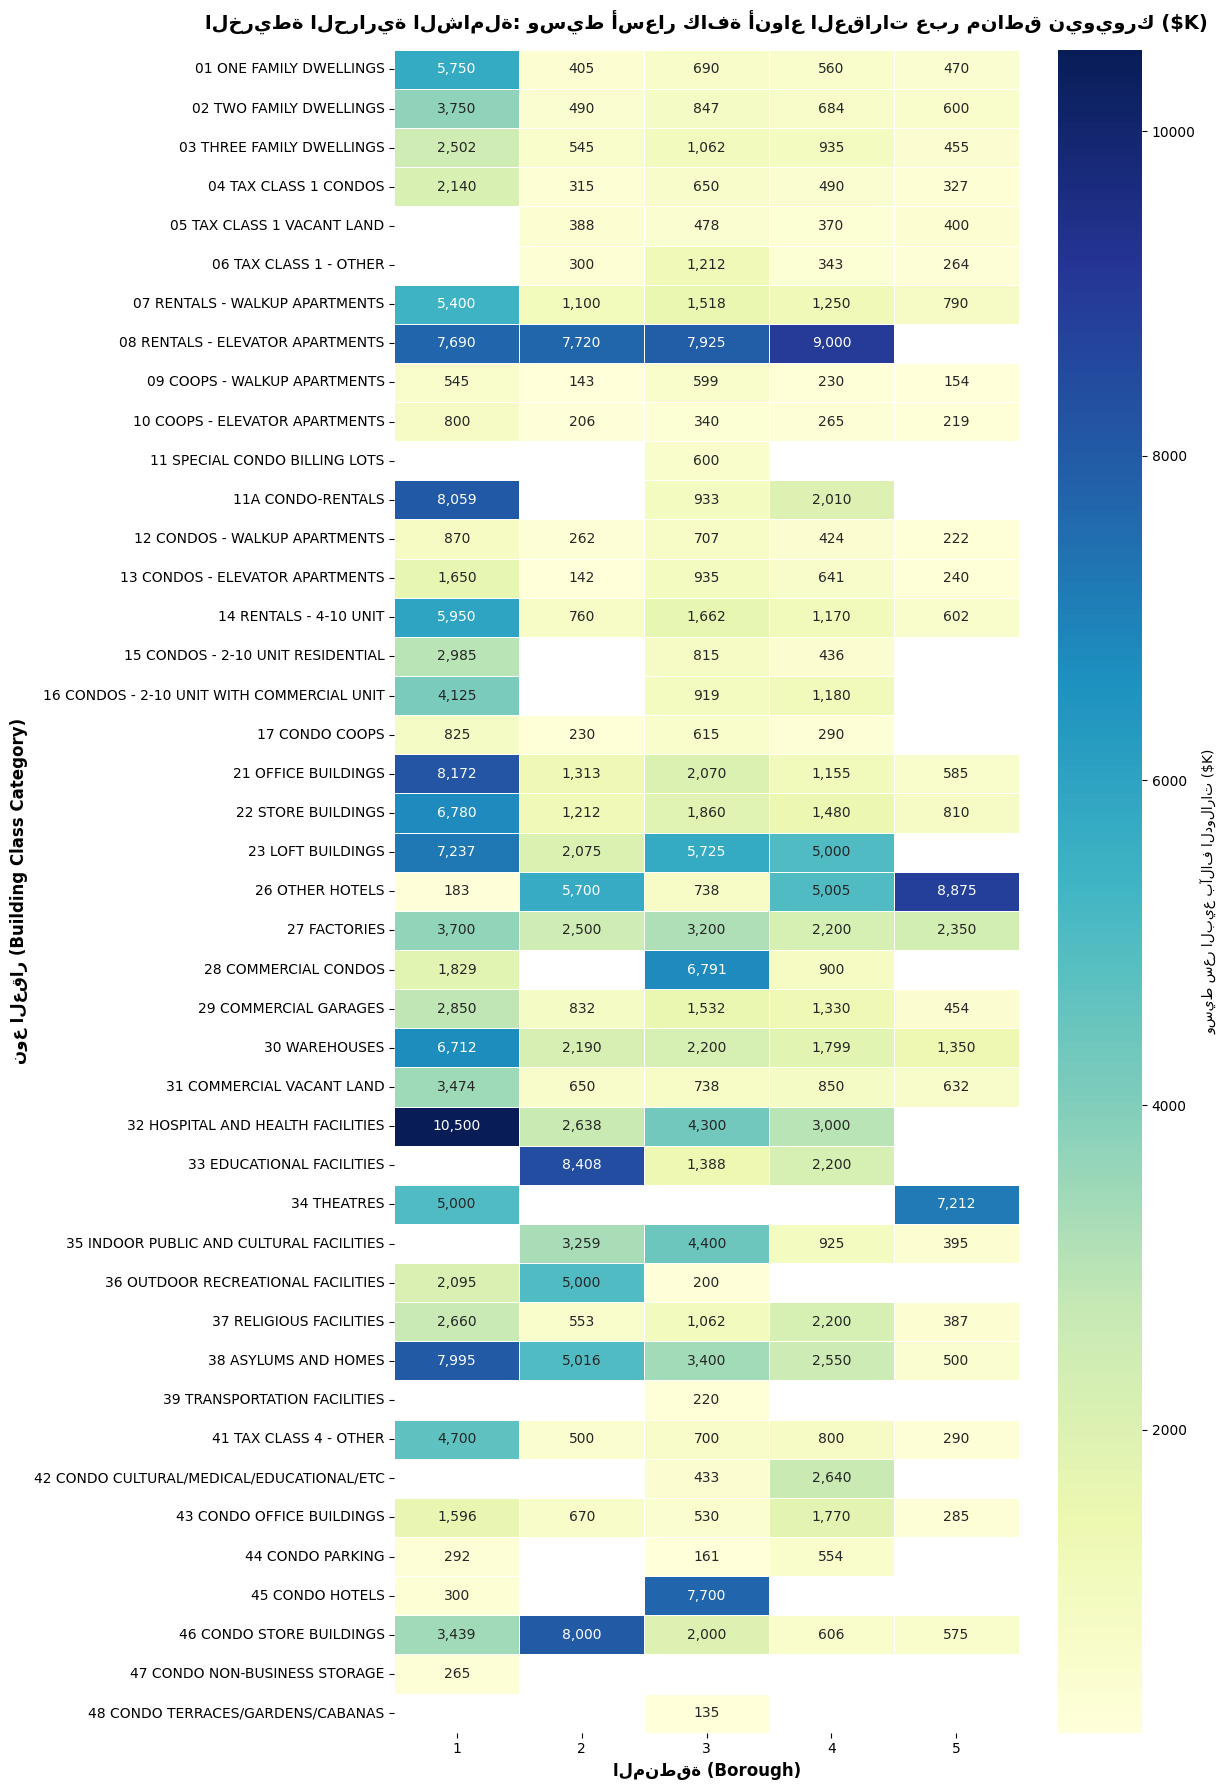

In [ ]:
# ========================================================
# الخريطة الحرارية الشاملة لكافة فئات العقارات (47 فئة × 5 مناطق)
# ========================================================

# استيراد المكتبات صراحة داخل الخلية
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إنشاء الجدول المحوري لكامل البيانات دون استبعاد أي فئة
# نحسب وسيط السعر مقسوماً على 1,000 ليكون العرض بآلاف الدولارات ($K)
pivot_all = df.pivot_table(
    index='BUILDING CLASS CATEGORY',
    columns='BOROUGH',
    values='SALE PRICE',
    aggfunc='median'
) / 1000

# 2. ضبط أبعاد اللوحة طولياً لاستيعاب الـ 47 فئة بارتياح
plt.figure(figsize=(12, 18))

# 3. رسم الخريطة الحرارية
sns.heatmap(
    pivot_all,
    annot=True,                 # كتابة الأرقام داخل الخلايا
    fmt=',.0f',                 # تنسيق الأرقام بدون فواصل عشرية
    cmap='YlGnBu',              # تدرج لوني من الأصفر إلى الأزرق الداكن
    linewidths=0.5,             # خطوط بيضاء رفيعة تفصل بين الخلايا
    cbar_kws={'label': 'وسيط سعر البيع بآلاف الدولارات ($K)'}
)

plt.title('الخريطة الحرارية الشاملة: وسيط أسعار كافة أنواع العقارات عبر مناطق نيويورك ($K)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('المنطقة (Borough)', fontsize=12, fontweight='bold')
plt.ylabel('نوع العقار (Building Class Category)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

<Figure size 1600x1200 with 0 Axes>

/tmp/ipykernel_2788/2357411736.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


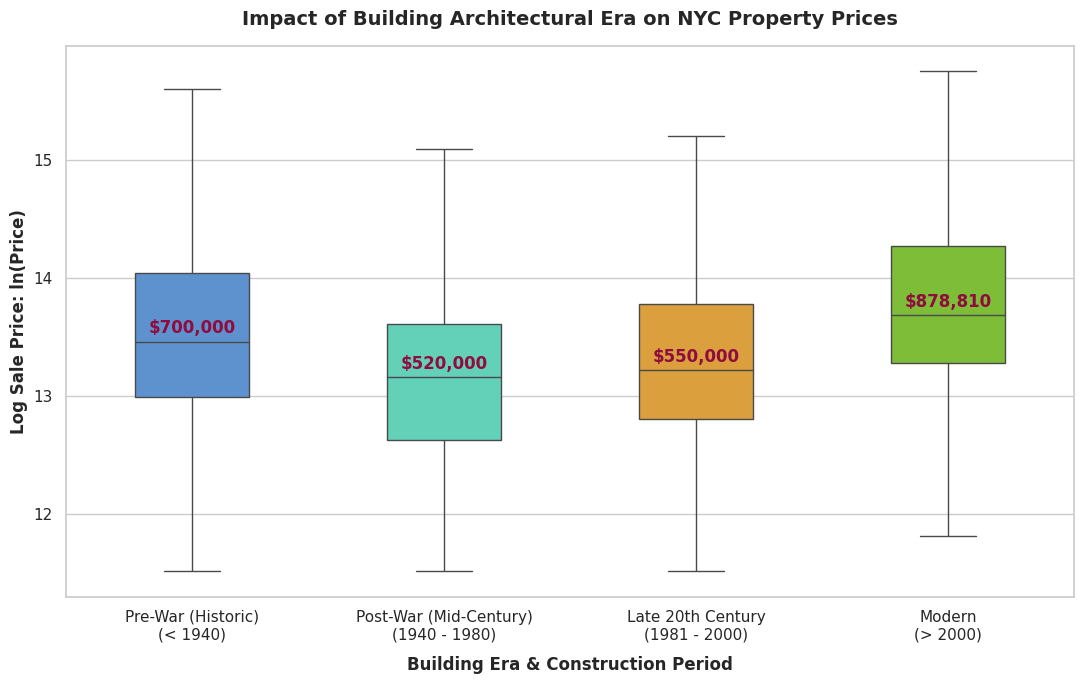

In [ ]:
# ========================================================
# Clean English Boxplot: Impact of Building Era on Sale Price
# ========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set canvas size and theme
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# 2. Format English labels with line breaks for optimal readability
era_labels = {
    'Pre-War (Historic)': 'Pre-War (Historic)\n(< 1940)',
    'Post-War (Mid-Century)': 'Post-War (Mid-Century)\n(1940 - 1980)',
    'Late 20th Century': 'Late 20th Century\n(1981 - 2000)',
    'Modern': 'Modern\n(> 2000)'
}

df['ERA_EN'] = df['BUILDING_ERA'].map(era_labels)
clean_order = list(era_labels.values())

# 3. Draw clean boxplot without outlier dots (showfliers=False)
ax = sns.boxplot(
    data=df,
    x='ERA_EN',
    y=np.log1p(df['SALE PRICE']),
    order=clean_order,
    palette=['#4a90e2', '#50e3c2', '#f5a623', '#7ed321'],
    width=0.45,
    showfliers=False  # Hide cluttered black dots for clean presentation
)

# 4. Annotate actual median prices in USD directly above each box
medians = df.groupby('ERA_EN')['SALE PRICE'].median()
log_medians = np.log1p(medians)

for i, era in enumerate(clean_order):
    real_price = medians[era]
    y_pos = log_medians[era]

    # Display formatted dollar value
    ax.text(
        i, y_pos + 0.07,
        f"${real_price:,.0f}",
        horizontalalignment='center',
        fontsize=12,
        fontweight='bold',
        color='#900C3F'
    )

# 5. Set English titles and axis labels
plt.title('Impact of Building Architectural Era on NYC Property Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Building Era & Construction Period', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Log Sale Price: ln(Price)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#دراسة وتصوير البيوت العائليه فقط

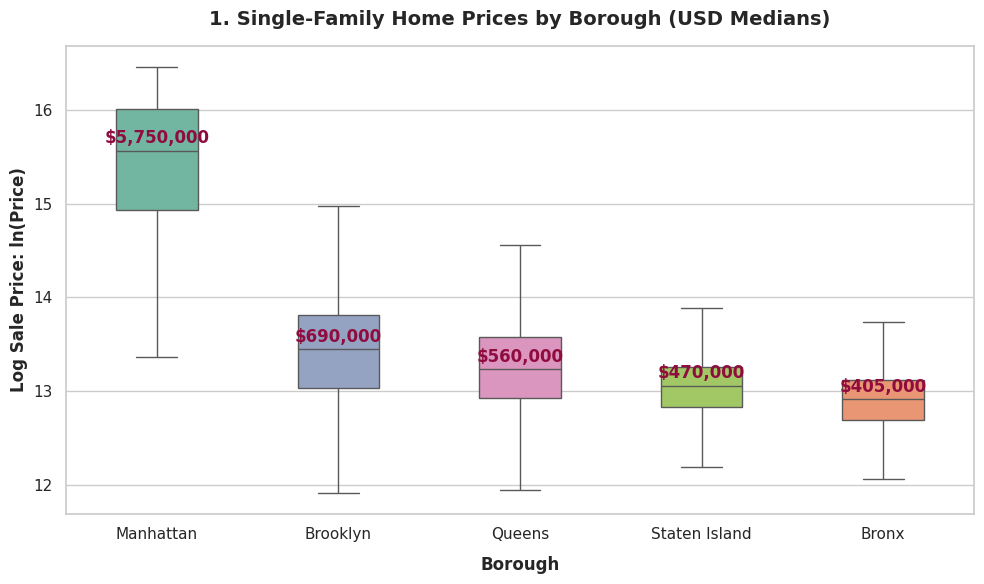

In [ ]:
# 1. عزل البيوت العائلية وتحويل أرقام المناطق إلى أسماء صريحة
df_family = df[df['BUILDING CLASS CATEGORY'] == '01 ONE FAMILY DWELLINGS'].copy()

borough_map = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'}
# إذا كان العمود أرقاماً، يتم تحويله للأسماء؛ وإن كان نصوصاً يبقى كما هو
if df_family['BOROUGH'].dtype in ['int64', 'float64'] or df_family['BOROUGH'].iloc[0] in [1, 2, 3, 4, 5, '1', '2', '3', '4', '5']:
    df_family['BOROUGH'] = df_family['BOROUGH'].astype(int).map(borough_map)

# 2. تحديد ترتيب العرض الجغرافي للمناطق الموجودة فعلياً
borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx']
borough_order = [b for b in borough_order if b in df_family['BOROUGH'].dropna().unique()]

# 3. إعداد لوحة الرسم
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax1 = sns.boxplot(
    data=df_family,
    x='BOROUGH',
    y=np.log1p(df_family['SALE PRICE']),
    order=borough_order,
    hue='BOROUGH',        # متوافق مع تحديثات Seaborn الحديثة لمنع التحذير
    legend=False,
    palette='Set2',
    width=0.45,
    showfliers=False      # لإزالة النقاط المشوشة والحفاظ على نقاء الرسم
)

# 4. كتابة وسيط السعر الحقيقي بالدولار فوق كل منطقة
medians_b = df_family.groupby('BOROUGH')['SALE PRICE'].median()
for i, b in enumerate(borough_order):
    price_val = medians_b[b]
    y_pos = np.log1p(price_val)
    ax1.text(i, y_pos + 0.08, f"${price_val:,.0f}", ha='center', fontsize=12, fontweight='bold', color='#900C3F')

plt.title('1. Single-Family Home Prices by Borough (USD Medians)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Borough', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Log Sale Price: ln(Price)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

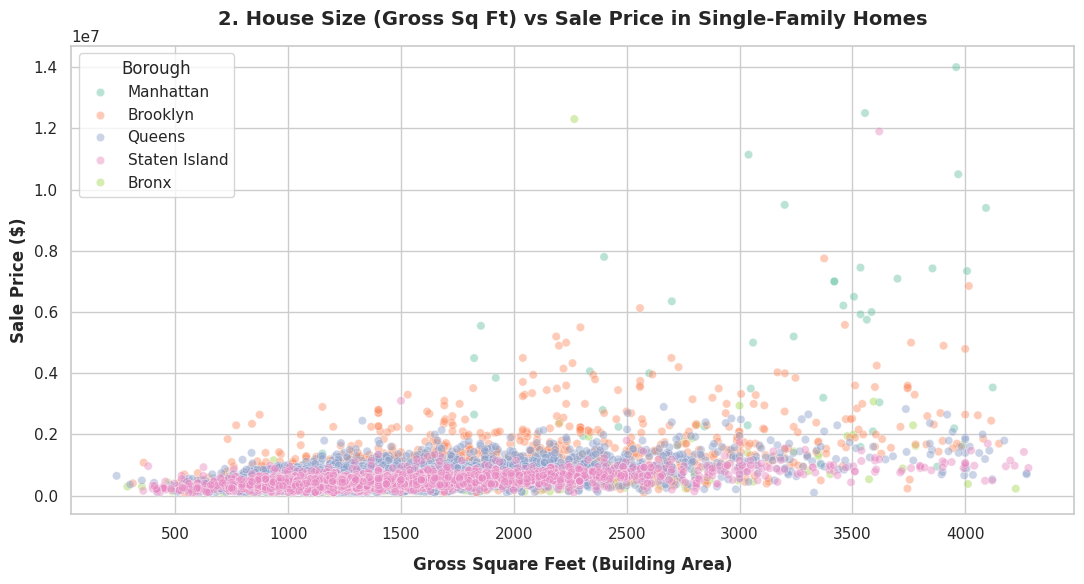

In [ ]:
# ========================================================
# الخلية 2: مساحة البيت وسعره حسب المنطقة
# ========================================================

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 1. استبعاد أعلى 1% من المساحات الشاذة جداً لتكون الرؤية واضحة
area_cap = df_family['GROSS SQUARE FEET'].quantile(0.99)
df_family_plot = df_family[df_family['GROSS SQUARE FEET'] <= area_cap]

# 2. رسم مخطط الانتشار ملوناً حسب المناطق
sns.scatterplot(
    data=df_family_plot,
    x='GROSS SQUARE FEET',
    y='SALE PRICE',
    hue='BOROUGH',
    hue_order=['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx'],
    alpha=0.45,
    palette='Set2'
)

# 3. العناوين والمحاور
plt.title('2. House Size (Gross Sq Ft) vs Sale Price in Single-Family Homes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gross Square Feet (Building Area)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
plt.legend(title='Borough', loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

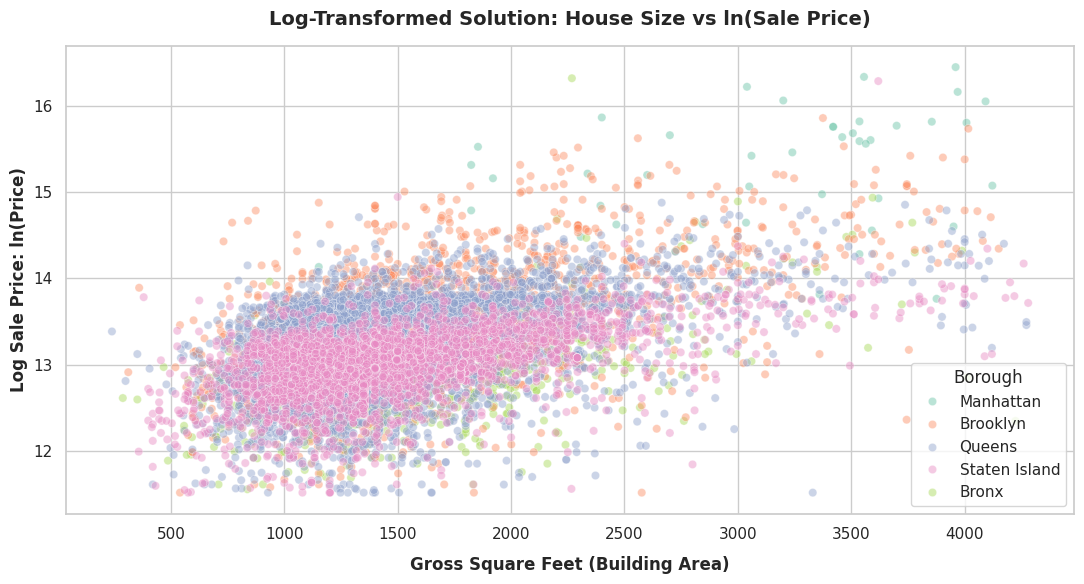

In [ ]:
# ========================================================
# تطبيق الحل اللوغاريتمي: إغلاق "المروحة" وضبط التباين
# ========================================================

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 1. تصفية أعلى 1% من المساحات الشاذة للرؤية النقية
area_cap = df_family['GROSS SQUARE FEET'].quantile(0.99)
df_family_plot = df_family[df_family['GROSS SQUARE FEET'] <= area_cap].copy()

# 2. تطبيق اللوغاريتم على السعر (الحل الرياضي)
df_family_plot['LOG_SALE_PRICE'] = np.log1p(df_family_plot['SALE PRICE'])

# 3. رسم مخطط الانتشار بعد التحويل اللوغاريتمي
sns.scatterplot(
    data=df_family_plot,
    x='GROSS SQUARE FEET',
    y='LOG_SALE_PRICE',
    hue='BOROUGH',
    hue_order=['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx'],
    alpha=0.45,
    palette='Set2'
)

# 4. العناوين والمحاور
plt.title('Log-Transformed Solution: House Size vs ln(Sale Price)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gross Square Feet (Building Area)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Log Sale Price: ln(Price)', fontsize=12, fontweight='bold')
plt.legend(title='Borough', loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
# ========================================================
# كتلة الترميز + التقسيم + تدريب نموذج خط الأساس
# ========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. تجهيز ميزة متوسط مساحة الوحدة وضبط فئة الضريبة
safe_units = df['TOTAL UNITS'].replace(0, 1)
df['UNIT_SIZE'] = df['GROSS SQUARE FEET'] / safe_units
df['TAX_CLASS_SALE'] = 'Tax_Class_' + df['TAX CLASS AT TIME OF SALE'].astype(str)

# 2. تحديد قوائم الميزات
categorical_cols = ['BOROUGH', 'BUILDING CLASS CATEGORY', 'BUILDING_ERA', 'TAX_CLASS_SALE']
numeric_cols = ['LAND SQUARE FEET', 'GROSS SQUARE FEET', 'TOTAL UNITS', 'AGE', 'UNIT_SIZE', 'SALE_MONTH']

# 3. بناء مصفوفة المدخلات وتطبيق One-Hot Encoding
X = df[categorical_cols + numeric_cols].copy()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. متغير الهدف اللوغاريتمي y
y = np.log1p(df['SALE PRICE'])

# 5. تقسيم البيانات: 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. تدريب نموذج الانحدار الخطي (Baseline Model)
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 7. التنبؤ على بيانات الاختبار
y_pred_log = baseline_model.predict(X_test)

# 8. حساب مقاييس الدقة على المقياس اللوغاريتمي
r2 = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

# 9. إعادة الأسعار إلى الدولار الحقيقي لحساب متوسط الخطأ المالي الفعلي
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

# طباعة التقرير الشامل
print("=" * 55)
print("تقرير أداء نموذج خط الأساس (Linear Regression Baseline):")
print("=" * 55)
print(f"عدد الميزات الناتجة بعد الترميز: {X_train.shape[1]} ميزة")
print(f"معامل التحديد (R² Score):       {r2:.4f} (نسبة التباين المفسرة)")
print(f"نسبة الخطأ اللوغاريتمي (RMSE):   {rmse_log:.4f}")
print(f"متوسط الخطأ المالي الفعلي (MAE): ${mae_real:,.0f} دولار")
print("=" * 55)

تقرير أداء نموذج خط الأساس (Linear Regression Baseline):
عدد الميزات الناتجة بعد الترميز: 57 ميزة
معامل التحديد (R² Score):       0.4684 (نسبة التباين المفسرة)
نسبة الخطأ اللوغاريتمي (RMSE):   0.6291
متوسط الخطأ المالي الفعلي (MAE): $561,735 دولار


In [ ]:
# ========================================================
# تدريب نموذج الغابات العشوائية (Random Forest Regressor)
# ========================================================

from sklearn.ensemble import RandomForestRegressor

# 1. بناء النموذج وضبط أهم المعاملات
# n_estimators=100: عدد الأشجار في الغابة
# max_depth=15: تحديد أقصى عمق لكل شجرة لمنع فرط التخصيص (Overfitting)
# n_jobs=-1: استخدام كافة أنوية المعالج لتسريع الحسابات
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# 2. تدريب نموذج الغابات على نفس بيانات التدريب
rf_model.fit(X_train, y_train)

# 3. التنبؤ على بيانات الاختبار
y_pred_rf_log = rf_model.predict(X_test)

# 4. حساب مقاييس الأداء الجديدة
rf_r2 = r2_score(y_test, y_pred_rf_log)
rf_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_rf_log))

# 5. حساب الخطأ المالي الفعلي بالدولار
y_pred_rf_real = np.expm1(y_pred_rf_log)
rf_mae_real = mean_absolute_error(y_test_real, y_pred_rf_real)

# طباعة المقارنة المباشرة بين النموذجين
print("=" * 60)
print("مقارنة الأداء: خط الأساس (خطي) مقابل الغابات العشوائية:")
print("=" * 60)
print(f"معامل التحديد القديم (Linear R²):    {r2:.4f}")
print(f"معامل التحديد الجديد (Random Forest R²): {rf_r2:.4f}")
print("-" * 60)
print(f"متوسط الخطأ المالي القديم (Linear MAE):     ${mae_real:,.0f}")
print(f"متوسط الخطأ المالي الجديد (Random Forest MAE): ${rf_mae_real:,.0f}")
print("=" * 60)

مقارنة الأداء: خط الأساس (خطي) مقابل الغابات العشوائية:
معامل التحديد القديم (Linear R²):    0.4684
معامل التحديد الجديد (Random Forest R²): 0.6003
------------------------------------------------------------
متوسط الخطأ المالي القديم (Linear MAE):     $561,735
متوسط الخطأ المالي الجديد (Random Forest MAE): $469,615


/tmp/ipykernel_2788/2311419128.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


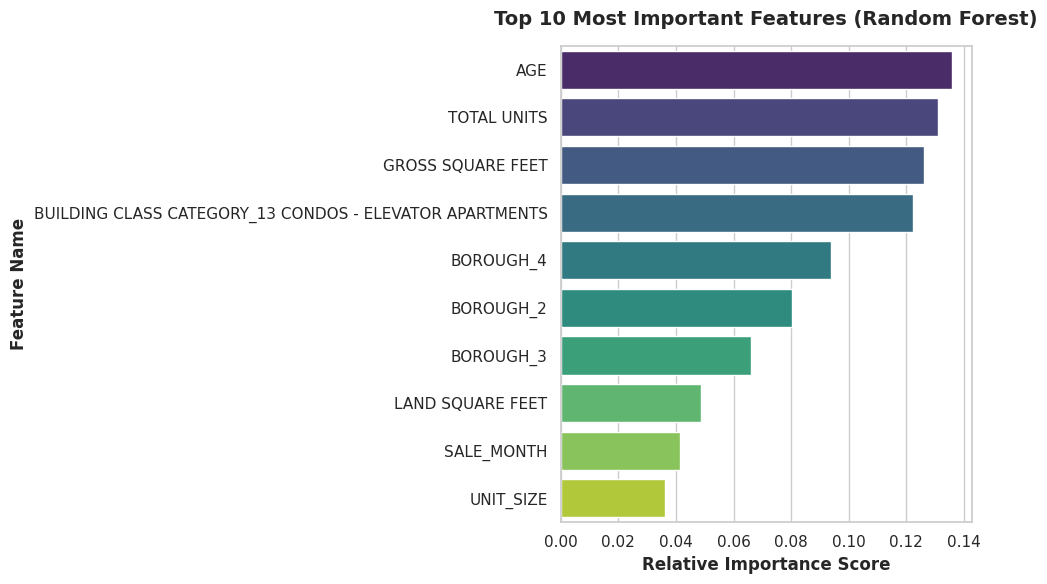

In [ ]:
# ========================================================
# استخراج وترتيب أهم 10 ميزات في نموذج الغابات العشوائية
# ========================================================

# 1. استخراج أوزان الأهمية للميزات من النموذج المدرب
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. إنشاء جدول مرتب تنازلياً بأهم الميزات
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# 3. رسم أعلى 10 ميزات تأثيراً
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 10 Most Important Features (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature Name', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ========================================================
# اختبار حساب الثقة على عقار حقيقي من بيانات الاختبار
# ========================================================

# 1. اختيار أول عقار من بيانات الاختبار (X_test)
sample_property = X_test.iloc[[0]]
actual_price = np.expm1(y_test.iloc[0])

# 2. استخراج تنبؤات كل شجرة من الأشجار الـ 100
tree_preds = [np.expm1(tree.predict(sample_property))[0] for tree in rf_model.estimators_]

# 3. حساب السعر التقديري وحدود الثقة ونسبة التماسك
estimated_price = np.mean(tree_preds)
lower_bound = np.percentile(tree_preds, 10)
upper_bound = np.percentile(tree_preds, 90)

# حساب نسبة الثقة
std_dev = np.std(tree_preds)
confidence_ratio = max(0, 1 - (std_dev / estimated_price))
confidence_score = round(confidence_ratio * 100, 1)

# 4. طباعة بطاقة التقييم
print("=" * 50)
print("بطاقة تقييم العقار التجريبي (Property Evaluation Card):")
print("=" * 50)
print(f"السعر الحقيقي الفعلي:       ${actual_price:,.0f} دولار")
print(f"السعر التقديري للنموذج:     ${estimated_price:,.0f} دولار")
print(f"النطاق السعري المرجح (80%): من ${lower_bound:,.0f} إلى ${upper_bound:,.0f}")
print(f"درجة ثقة وتماسك النموذج:    {confidence_score}%")
print("=" * 50)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWa

بطاقة تقييم العقار التجريبي (Property Evaluation Card):
السعر الحقيقي الفعلي:       $352,000 دولار
السعر التقديري للنموذج:     $341,029 دولار
النطاق السعري المرجح (80%): من $284,706 إلى $423,520
درجة ثقة وتماسك النموذج:    84.9%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWa

In [ ]:
# ========================================================
# 1. حفظ النموذج وقائمة الميزات
# ========================================================
import joblib

# حفظ النموذج المدرب
joblib.dump(rf_model, 'nyc_rf_model.pkl')

# حفظ أسماء الأعمدة الـ 57 بالترتيب الدقيق
joblib.dump(list(X_train.columns), 'model_features.pkl')

print("✅ تم حفظ الملفين بنجاح في بيئة العمل.")

✅ تم حفظ الملفين بنجاح في بيئة العمل.


In [ ]:
from google.colab import files
files.download('nyc_rf_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>